# Nonlinear contrastive encoders: can they distinguish signal from noise?

This notebook extends the linear contrastive-encoder experiments to **nonlinear MLP encoders**.

The central question is not whether an encoder can obtain a high training score. A sufficiently flexible model may memorize accidental pairings between unrelated samples. The useful question is:

> After fitting on training pairs, does the learned representation remain aligned on unseen paired samples, while collapsing to the shuffled-pair baseline when the pairing is broken?

The notebook runs three kinds of data:

1. **Null data:** `X` and `Y` are independent Gaussian noise. A reliable encoder should have near-zero held-out alignment.
2. **Linear shared signal:** both views contain a common hidden factor plus independent noise.
3. **Nonlinear shared signal:** the views share a hidden factor through a nonlinear relationship. This tests whether an MLP can recover a stable nonlinear dependency rather than memorize sample identities.

It compares linear and nonlinear encoders, sweeps nonlinear model capacity, tests regularization, and performs an observation-noise sweep.

Set `QUICK_MODE = True` for a laptop-friendly first run. Increase replications and epochs only after confirming that the notebook runs correctly.

## How the evaluation works

Each encoder is trained only on `(X_train, Y_train)`.

After training, the model is frozen and evaluated on new rows `(X_test, Y_test)` generated from the same data-generating mechanism. This is the nonlinear analogue of held-out CCA alignment.

For multidimensional embeddings, a single Pearson correlation is not enough. The notebook therefore records:

- **Alignment gap:** mean cosine similarity of correct pairs minus mean cosine similarity of mismatched pairs.
- **Top-1 retrieval:** fraction of rows whose correct partner is the most similar row in the other view.
- **Shuffled held-out gap:** held-out alignment after permuting the rows of `Y_test`; this should be near zero.
- **Target probe R²:** a ridge probe is fitted from the *training embeddings* to the known shared synthetic factor and evaluated on test embeddings. This checks whether the learned representation contains the intended latent information.
- **Effective rank:** checks whether an apparently safe model merely collapsed its embeddings.

A nonlinear encoder passes the noise test only if it does **not** produce meaningful held-out alignment on null data. A useful nonlinear encoder should also preserve held-out alignment and target recovery when a real shared factor exists.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, replace
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
except ImportError as exc:
    raise ImportError(
        "PyTorch is required. Install it with: pip install torch"
    ) from exc

GLOBAL_SEED = 123
QUICK_MODE = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("QUICK_MODE =", QUICK_MODE)
torch.set_num_threads(max(1, min(4, torch.get_num_threads())))

print("DEVICE =", DEVICE)
print("TORCH_NUM_THREADS =", torch.get_num_threads())

QUICK_MODE = False
DEVICE = cpu
TORCH_NUM_THREADS = 4


## 1. Synthetic paired datasets

The nonlinear scenario is intentionally simple and interpretable.

Let `z` be a one-dimensional hidden variable. The `X` view contains a noisy linear measurement of `z`, while the `Y` view contains a noisy measurement of the centered quadratic factor

\[
 t = \frac{z^2 - 1}{\sqrt{2}}.
\]

A linear map from `X` cannot directly create `z²`, but an MLP can approximate this nonlinear transformation. The target probe evaluates whether the learned embeddings recover `t`.

The quadratic map discards the sign of `z`, so top-1 retrieval is not the main criterion in this scenario. The more relevant diagnostics are held-out alignment gap and target-probe recovery.

In [2]:
@dataclass
class PairedDataset:
    X_train: np.ndarray
    Y_train: np.ndarray
    X_test: np.ndarray
    Y_test: np.ndarray
    target_train: Optional[np.ndarray] = None
    target_test: Optional[np.ndarray] = None
    scenario: str = ""


def orthonormal_columns(
    rng: np.random.Generator,
    n_rows: int,
    n_cols: int,
) -> np.ndarray:
    """Return a matrix with orthonormal columns."""
    if n_cols > n_rows:
        raise ValueError("n_cols must not exceed n_rows")

    raw = rng.standard_normal((n_rows, n_cols))
    q, _ = np.linalg.qr(raw)
    return q[:, :n_cols]


def generate_null_dataset(
    n_train: int,
    n_test: int,
    p: int,
    q: int,
    rng: np.random.Generator,
) -> PairedDataset:
    """Independent Gaussian views: there is no shared signal."""
    return PairedDataset(
        X_train=rng.standard_normal((n_train, p)),
        Y_train=rng.standard_normal((n_train, q)),
        X_test=rng.standard_normal((n_test, p)),
        Y_test=rng.standard_normal((n_test, q)),
        scenario="Null",
    )


def generate_linear_signal_dataset(
    n_train: int,
    n_test: int,
    p: int,
    q: int,
    latent_dim: int,
    signal_strength: float,
    noise_std: float,
    rng: np.random.Generator,
) -> PairedDataset:
    """
    Both views contain the same latent factor through linear loadings:

        X = signal_strength * Z @ A_x.T + noise_x
        Y = signal_strength * Z @ A_y.T + noise_y
    """
    if latent_dim > min(p, q):
        raise ValueError("latent_dim must not exceed min(p, q)")

    loadings_x = orthonormal_columns(rng, p, latent_dim)
    loadings_y = orthonormal_columns(rng, q, latent_dim)

    Z_train = rng.standard_normal((n_train, latent_dim))
    Z_test = rng.standard_normal((n_test, latent_dim))

    X_train = (
        signal_strength * (Z_train @ loadings_x.T)
        + noise_std * rng.standard_normal((n_train, p))
    )
    Y_train = (
        signal_strength * (Z_train @ loadings_y.T)
        + noise_std * rng.standard_normal((n_train, q))
    )
    X_test = (
        signal_strength * (Z_test @ loadings_x.T)
        + noise_std * rng.standard_normal((n_test, p))
    )
    Y_test = (
        signal_strength * (Z_test @ loadings_y.T)
        + noise_std * rng.standard_normal((n_test, q))
    )

    return PairedDataset(
        X_train=X_train,
        Y_train=Y_train,
        X_test=X_test,
        Y_test=Y_test,
        target_train=Z_train,
        target_test=Z_test,
        scenario="Linear signal",
    )


def generate_quadratic_signal_dataset(
    n_train: int,
    n_test: int,
    p: int,
    q: int,
    signal_strength: float,
    noise_std: float,
    rng: np.random.Generator,
) -> PairedDataset:
    """
    A nonlinear paired relationship:

        z ~ Normal(0, 1)
        target = (z^2 - 1) / sqrt(2)

        X = signal_strength * z      * a_x.T + noise_x
        Y = signal_strength * target * a_y.T + noise_y

    The shared recoverable quantity is `target`, not the sign of z.
    """
    loading_x = orthonormal_columns(rng, p, 1)
    loading_y = orthonormal_columns(rng, q, 1)

    z_train = rng.standard_normal((n_train, 1))
    z_test = rng.standard_normal((n_test, 1))

    target_train = (z_train**2 - 1.0) / np.sqrt(2.0)
    target_test = (z_test**2 - 1.0) / np.sqrt(2.0)

    X_train = (
        signal_strength * (z_train @ loading_x.T)
        + noise_std * rng.standard_normal((n_train, p))
    )
    Y_train = (
        signal_strength * (target_train @ loading_y.T)
        + noise_std * rng.standard_normal((n_train, q))
    )
    X_test = (
        signal_strength * (z_test @ loading_x.T)
        + noise_std * rng.standard_normal((n_test, p))
    )
    Y_test = (
        signal_strength * (target_test @ loading_y.T)
        + noise_std * rng.standard_normal((n_test, q))
    )

    return PairedDataset(
        X_train=X_train,
        Y_train=Y_train,
        X_test=X_test,
        Y_test=Y_test,
        target_train=target_train,
        target_test=target_test,
        scenario="Quadratic signal",
    )

## 2. Train-only preprocessing

Centering, scaling, and optional ridge-stabilized whitening are fitted on the training rows only. The frozen transformation is then applied to the test rows.

In [3]:
@dataclass
class Preprocessor:
    mean: np.ndarray
    scale: np.ndarray
    whitener: Optional[np.ndarray] = None


def fit_preprocessor(
    X: np.ndarray,
    standardize: bool = True,
    whitening_ridge: Optional[float] = None,
) -> Preprocessor:
    X = np.asarray(X, dtype=float)
    mean = X.mean(axis=0, keepdims=True)

    if standardize:
        scale = X.std(axis=0, ddof=1, keepdims=True)
        scale = np.where(scale > 1e-12, scale, 1.0)
    else:
        scale = np.ones((1, X.shape[1]))

    Xs = (X - mean) / scale

    whitener = None
    if whitening_ridge is not None:
        if whitening_ridge < 0:
            raise ValueError("whitening_ridge must be non-negative")

        divisor = max(Xs.shape[0] - 1, 1)
        covariance = (Xs.T @ Xs) / divisor
        covariance = 0.5 * (covariance + covariance.T)

        values, vectors = np.linalg.eigh(covariance)
        values = np.maximum(values + whitening_ridge, 1e-10)
        whitener = (vectors / np.sqrt(values)) @ vectors.T

    return Preprocessor(mean=mean, scale=scale, whitener=whitener)


def apply_preprocessor(X: np.ndarray, prep: Preprocessor) -> np.ndarray:
    Xs = (np.asarray(X, dtype=float) - prep.mean) / prep.scale
    if prep.whitener is not None:
        Xs = Xs @ prep.whitener
    return Xs

## 3. Linear and nonlinear two-view encoders

The linear baseline is included for reference. The MLP encoder uses GELU activations and an adjustable hidden width, depth, dropout rate, and embedding bottleneck.

In [4]:
class LinearEncoder(nn.Module):
    def __init__(self, input_dim: int, embedding_dim: int):
        super().__init__()
        self.network = nn.Linear(input_dim, embedding_dim, bias=False)
        nn.init.orthogonal_(self.network.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class MLPEncoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        embedding_dim: int,
        hidden_dim: int,
        depth: int,
        dropout: float,
    ):
        super().__init__()

        if depth < 1:
            raise ValueError("MLP depth must be at least 1")

        layers: List[nn.Module] = []
        current_dim = input_dim

        for _ in range(depth):
            layers.extend(
                [
                    nn.Linear(current_dim, hidden_dim),
                    nn.GELU(),
                    nn.Dropout(dropout),
                ]
            )
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, embedding_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class TwoViewEncoder(nn.Module):
    def __init__(
        self,
        p: int,
        q: int,
        encoder_type: str,
        embedding_dim: int,
        hidden_dim: int,
        depth: int,
        dropout: float,
    ):
        super().__init__()

        if encoder_type == "linear":
            self.encoder_x = LinearEncoder(p, embedding_dim)
            self.encoder_y = LinearEncoder(q, embedding_dim)
        elif encoder_type == "mlp":
            self.encoder_x = MLPEncoder(
                p,
                embedding_dim,
                hidden_dim,
                depth,
                dropout,
            )
            self.encoder_y = MLPEncoder(
                q,
                embedding_dim,
                hidden_dim,
                depth,
                dropout,
            )
        else:
            raise ValueError("encoder_type must be 'linear' or 'mlp'")

    def forward(
        self,
        X: torch.Tensor,
        Y: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.encoder_x(X), self.encoder_y(Y)

## 4. Contrastive loss and evaluation metrics

`InfoNCE` uses each row's paired partner as the positive example and the remaining rows as negatives.

The probe is intentionally trained **after** representation learning. It does not affect encoder training. It asks whether a simple linear readout from the learned embedding recovers the known synthetic shared factor on unseen rows.

In [5]:
def symmetric_info_nce(
    z_x: torch.Tensor,
    z_y: torch.Tensor,
    temperature: float,
) -> torch.Tensor:
    if temperature <= 0:
        raise ValueError("temperature must be positive")

    z_x = F.normalize(z_x, dim=1)
    z_y = F.normalize(z_y, dim=1)

    logits = (z_x @ z_y.T) / temperature
    labels = torch.arange(logits.shape[0], device=logits.device)

    return 0.5 * (
        F.cross_entropy(logits, labels)
        + F.cross_entropy(logits.T, labels)
    )


def normalize_rows(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    return z / np.maximum(np.linalg.norm(z, axis=1, keepdims=True), 1e-12)


def alignment_gap(z_x: np.ndarray, z_y: np.ndarray) -> float:
    """Mean cosine similarity of matched pairs minus mismatched pairs."""
    z_x = normalize_rows(z_x)
    z_y = normalize_rows(z_y)

    similarities = z_x @ z_y.T
    matched = np.diag(similarities).mean()

    n = similarities.shape[0]
    if n <= 1:
        return float("nan")

    mismatched = (
        similarities.sum() - np.trace(similarities)
    ) / (similarities.size - n)

    return float(matched - mismatched)


def bidirectional_top1_accuracy(z_x: np.ndarray, z_y: np.ndarray) -> float:
    """Average X->Y and Y->X top-1 retrieval accuracy."""
    similarities = normalize_rows(z_x) @ normalize_rows(z_y).T
    labels = np.arange(similarities.shape[0])

    x_to_y = float((similarities.argmax(axis=1) == labels).mean())
    y_to_x = float((similarities.argmax(axis=0) == labels).mean())
    return 0.5 * (x_to_y + y_to_x)


def effective_rank(z: np.ndarray) -> float:
    """Entropy-based effective rank of centered embeddings."""
    z = np.asarray(z, dtype=float)
    z = z - z.mean(axis=0, keepdims=True)
    singular_values = np.linalg.svd(z, compute_uv=False)
    energy = singular_values**2

    if energy.sum() <= 1e-12:
        return 0.0

    probabilities = energy / energy.sum()
    probabilities = probabilities[probabilities > 1e-12]
    entropy = -(probabilities * np.log(probabilities)).sum()
    return float(np.exp(entropy))


def fit_ridge_probe(
    z_train: np.ndarray,
    target_train: np.ndarray,
    ridge: float = 1e-3,
) -> np.ndarray:
    """Fit a ridge probe with an unpenalized intercept."""
    z_train = np.asarray(z_train, dtype=float)
    target_train = np.asarray(target_train, dtype=float)

    design = np.column_stack([np.ones(z_train.shape[0]), z_train])
    penalty = ridge * np.eye(design.shape[1])
    penalty[0, 0] = 0.0

    return np.linalg.solve(
        design.T @ design + penalty,
        design.T @ target_train,
    )


def apply_ridge_probe(z: np.ndarray, coefficients: np.ndarray) -> np.ndarray:
    design = np.column_stack([np.ones(z.shape[0]), z])
    return design @ coefficients


def r2_score(target: np.ndarray, prediction: np.ndarray) -> float:
    target = np.asarray(target, dtype=float)
    prediction = np.asarray(prediction, dtype=float)

    numerator = np.sum((target - prediction) ** 2)
    denominator = np.sum((target - target.mean(axis=0, keepdims=True)) ** 2)

    if denominator <= 1e-12:
        return float("nan")

    return float(1.0 - numerator / denominator)


def probe_r2(
    z_train: np.ndarray,
    z_test: np.ndarray,
    target_train: Optional[np.ndarray],
    target_test: Optional[np.ndarray],
    ridge: float = 1e-3,
) -> float:
    if target_train is None or target_test is None:
        return float("nan")

    coefficients = fit_ridge_probe(z_train, target_train, ridge=ridge)
    prediction = apply_ridge_probe(z_test, coefficients)
    return r2_score(target_test, prediction)

## 5. Training configuration and training loop

The default optimizer is `AdamW`. The optional interventions are deliberately simple:

- smaller embedding dimension;
- weight decay;
- dropout inside the MLP;
- feature dropout at the input;
- Gaussian input-noise augmentation;
- consistency penalty between clean and perturbed embeddings;
- train-only ridge-stabilized whitening.

These do not guarantee success. The notebook measures whether they reduce null memorization without destroying recoverable signal.

In [6]:
@dataclass(frozen=True)
class TrainConfig:
    name: str
    encoder_type: str = "mlp"
    embedding_dim: int = 8
    hidden_dim: int = 128
    depth: int = 2

    epochs: int = 120
    learning_rate: float = 3e-3
    temperature: float = 0.20
    weight_decay: float = 0.0

    dropout: float = 0.0
    feature_dropout: float = 0.0
    gaussian_noise_std: float = 0.0
    consistency_strength: float = 0.0
    consistency_noise_std: float = 0.10

    standardize_inputs: bool = True
    whitening_ridge: Optional[float] = None


def perturb_inputs(
    X: torch.Tensor,
    feature_dropout: float,
    gaussian_noise_std: float,
) -> torch.Tensor:
    result = X

    if feature_dropout > 0:
        result = F.dropout(result, p=feature_dropout, training=True)

    if gaussian_noise_std > 0:
        result = result + gaussian_noise_std * torch.randn_like(result)

    return result


def train_and_evaluate(
    dataset: PairedDataset,
    config: TrainConfig,
    seed: int,
) -> Dict[str, float]:
    torch.manual_seed(seed)
    np.random.seed(seed)

    prep_x = fit_preprocessor(
        dataset.X_train,
        standardize=config.standardize_inputs,
        whitening_ridge=config.whitening_ridge,
    )
    prep_y = fit_preprocessor(
        dataset.Y_train,
        standardize=config.standardize_inputs,
        whitening_ridge=config.whitening_ridge,
    )

    X_train_np = apply_preprocessor(dataset.X_train, prep_x)
    Y_train_np = apply_preprocessor(dataset.Y_train, prep_y)
    X_test_np = apply_preprocessor(dataset.X_test, prep_x)
    Y_test_np = apply_preprocessor(dataset.Y_test, prep_y)

    X_train = torch.tensor(X_train_np, dtype=torch.float32, device=DEVICE)
    Y_train = torch.tensor(Y_train_np, dtype=torch.float32, device=DEVICE)
    X_test = torch.tensor(X_test_np, dtype=torch.float32, device=DEVICE)
    Y_test = torch.tensor(Y_test_np, dtype=torch.float32, device=DEVICE)

    model = TwoViewEncoder(
        p=X_train.shape[1],
        q=Y_train.shape[1],
        encoder_type=config.encoder_type,
        embedding_dim=config.embedding_dim,
        hidden_dim=config.hidden_dim,
        depth=config.depth,
        dropout=config.dropout,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
    )

    final_loss = float("nan")
    model.train()

    for _ in range(config.epochs):
        optimizer.zero_grad(set_to_none=True)

        X_batch = perturb_inputs(
            X_train,
            feature_dropout=config.feature_dropout,
            gaussian_noise_std=config.gaussian_noise_std,
        )
        Y_batch = perturb_inputs(
            Y_train,
            feature_dropout=config.feature_dropout,
            gaussian_noise_std=config.gaussian_noise_std,
        )

        z_x, z_y = model(X_batch, Y_batch)
        loss = symmetric_info_nce(z_x, z_y, config.temperature)

        if config.consistency_strength > 0:
            X_aug = perturb_inputs(
                X_train,
                feature_dropout=config.feature_dropout,
                gaussian_noise_std=config.consistency_noise_std,
            )
            Y_aug = perturb_inputs(
                Y_train,
                feature_dropout=config.feature_dropout,
                gaussian_noise_std=config.consistency_noise_std,
            )

            clean_x, clean_y = model(X_train, Y_train)
            aug_x, aug_y = model(X_aug, Y_aug)

            consistency = (
                (F.normalize(clean_x, dim=1) - F.normalize(aug_x, dim=1))
                .pow(2)
                .mean()
                + (F.normalize(clean_y, dim=1) - F.normalize(aug_y, dim=1))
                .pow(2)
                .mean()
            )

            loss = loss + config.consistency_strength * consistency

        loss.backward()
        optimizer.step()
        final_loss = float(loss.detach().cpu())

    model.eval()

    with torch.no_grad():
        z_x_train, z_y_train = model(X_train, Y_train)
        z_x_test, z_y_test = model(X_test, Y_test)

    z_x_train = z_x_train.cpu().numpy()
    z_y_train = z_y_train.cpu().numpy()
    z_x_test = z_x_test.cpu().numpy()
    z_y_test = z_y_test.cpu().numpy()

    rng = np.random.default_rng(seed + 10_000)
    permutation = rng.permutation(z_y_test.shape[0])

    return {
        "train_alignment_gap": alignment_gap(z_x_train, z_y_train),
        "test_alignment_gap": alignment_gap(z_x_test, z_y_test),
        "shuffled_test_alignment_gap": alignment_gap(
            z_x_test,
            z_y_test[permutation],
        ),
        "train_top1": bidirectional_top1_accuracy(z_x_train, z_y_train),
        "test_top1": bidirectional_top1_accuracy(z_x_test, z_y_test),
        "target_probe_r2_x": probe_r2(
            z_x_train,
            z_x_test,
            dataset.target_train,
            dataset.target_test,
        ),
        "target_probe_r2_y": probe_r2(
            z_y_train,
            z_y_test,
            dataset.target_train,
            dataset.target_test,
        ),
        "effective_rank_x": effective_rank(z_x_test),
        "effective_rank_y": effective_rank(z_y_test),
        "mean_embedding_norm_x": float(np.linalg.norm(z_x_test, axis=1).mean()),
        "mean_embedding_norm_y": float(np.linalg.norm(z_y_test, axis=1).mean()),
        "final_loss": final_loss,
    }

## 6. Experiment runner and plotting helpers

In [7]:
def build_dataset(
    scenario: str,
    n_train: int,
    n_test: int,
    p: int,
    q: int,
    signal_strength: float,
    noise_std: float,
    rng: np.random.Generator,
) -> PairedDataset:
    if scenario == "Null":
        return generate_null_dataset(n_train, n_test, p, q, rng)

    if scenario == "Linear signal":
        return generate_linear_signal_dataset(
            n_train=n_train,
            n_test=n_test,
            p=p,
            q=q,
            latent_dim=1,
            signal_strength=signal_strength,
            noise_std=noise_std,
            rng=rng,
        )

    if scenario == "Quadratic signal":
        return generate_quadratic_signal_dataset(
            n_train=n_train,
            n_test=n_test,
            p=p,
            q=q,
            signal_strength=signal_strength,
            noise_std=noise_std,
            rng=rng,
        )

    raise ValueError(f"Unknown scenario: {scenario}")


def run_config_grid(
    configs: Sequence[TrainConfig],
    scenarios: Sequence[str],
    n_train: int,
    n_test: int,
    p: int,
    q: int,
    n_rep: int,
    signal_strength: float,
    noise_std: float,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    records: List[Dict[str, float]] = []

    total_runs = n_rep * len(scenarios) * len(configs)
    completed = 0
    start_time = time.time()

    for rep in range(n_rep):
        for scenario in scenarios:
            dataset = build_dataset(
                scenario=scenario,
                n_train=n_train,
                n_test=n_test,
                p=p,
                q=q,
                signal_strength=signal_strength,
                noise_std=noise_std,
                rng=rng,
            )

            for config_index, config in enumerate(configs):
                metrics = train_and_evaluate(
                    dataset=dataset,
                    config=config,
                    seed=seed + 1000 * rep + config_index,
                )

                records.append(
                    {
                        "rep": rep,
                        "scenario": scenario,
                        "config": config.name,
                        **metrics,
                    }
                )

                completed += 1
                if completed == total_runs or completed % max(1, total_runs // 5) == 0:
                    elapsed = time.time() - start_time
                    print(f"Completed {completed:>3}/{total_runs} runs in {elapsed:6.1f}s")

    return pd.DataFrame(records)


def summarize_results(results: pd.DataFrame) -> pd.DataFrame:
    numeric_columns = [
        column
        for column in results.columns
        if column not in {"rep", "scenario", "config"}
    ]

    return (
        results.groupby(["scenario", "config"], as_index=False)[numeric_columns]
        .mean()
    )


def average_probe_r2(frame: pd.DataFrame) -> pd.Series:
    return 0.5 * (
        frame["target_probe_r2_x"]
        + frame["target_probe_r2_y"]
    )


def plot_null_alignment(results: pd.DataFrame, title: str) -> None:
    summary = summarize_results(results)
    subset = summary[summary["scenario"] == "Null"].copy()

    x = np.arange(len(subset))
    width = 0.38

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(
        x - width / 2,
        subset["train_alignment_gap"],
        width=width,
        label="Training gap",
    )
    ax.bar(
        x + width / 2,
        subset["test_alignment_gap"],
        width=width,
        label="Held-out gap",
    )

    ax.axhline(0.0, linestyle=":")
    ax.set_xticks(x)
    ax.set_xticklabels(subset["config"], rotation=25, ha="right")
    ax.set(
        title=title,
        xlabel="Encoder configuration",
        ylabel="Matched cosine similarity minus mismatched similarity",
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_signal_metrics(results: pd.DataFrame, scenario: str, title: str) -> None:
    summary = summarize_results(results)
    subset = summary[summary["scenario"] == scenario].copy()
    subset["mean_target_probe_r2"] = average_probe_r2(subset)

    x = np.arange(len(subset))
    width = 0.26

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(
        x - width,
        subset["test_alignment_gap"],
        width=width,
        label="Held-out alignment gap",
    )
    ax.bar(
        x,
        subset["shuffled_test_alignment_gap"],
        width=width,
        label="Shuffled held-out gap",
    )
    ax.bar(
        x + width,
        subset["mean_target_probe_r2"],
        width=width,
        label="Mean target-probe R²",
    )

    ax.axhline(0.0, linestyle=":")
    ax.set_xticks(x)
    ax.set_xticklabels(subset["config"], rotation=25, ha="right")
    ax.set(
        title=title,
        xlabel="Encoder configuration",
        ylabel="Metric value",
        ylim=(-0.25, 1.05),
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_retrieval(results: pd.DataFrame, scenario: str, title: str) -> None:
    summary = summarize_results(results)
    subset = summary[summary["scenario"] == scenario].copy()

    x = np.arange(len(subset))
    width = 0.38

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - width / 2, subset["train_top1"], width=width, label="Training top-1")
    ax.bar(x + width / 2, subset["test_top1"], width=width, label="Held-out top-1")

    ax.axhline(1.0 / N_TEST, linestyle=":", label="Held-out chance level")
    ax.set_xticks(x)
    ax.set_xticklabels(subset["config"], rotation=25, ha="right")
    ax.set(
        title=title,
        xlabel="Encoder configuration",
        ylabel="Bidirectional top-1 retrieval accuracy",
        ylim=(-0.02, 1.02),
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Shared experiment size

The quick settings intentionally keep runtime modest. The full settings are better for a final figure because neural-network optimization has random variation.

In [8]:
N_TRAIN = 96 if QUICK_MODE else 400
N_TEST = 300 if QUICK_MODE else 2500
P = 64 if QUICK_MODE else 320
Q = 64 if QUICK_MODE else 320
N_REP = 1 if QUICK_MODE else 6
EPOCHS = 40 if QUICK_MODE else 300
HIDDEN_BASE = 64 if QUICK_MODE else 128

SIGNAL_STRENGTH = 3.0
NOISE_STD = 1.0

LINEAR_BASELINE = TrainConfig(
    name="Linear baseline",
    encoder_type="linear",
    embedding_dim=8,
    epochs=EPOCHS,
)

MLP_BASELINE = TrainConfig(
    name="MLP baseline",
    encoder_type="mlp",
    embedding_dim=8,
    hidden_dim=HIDDEN_BASE,
    depth=2,
    epochs=EPOCHS,
)

print(
    {
        "N_TRAIN": N_TRAIN,
        "N_TEST": N_TEST,
        "P": P,
        "Q": Q,
        "N_REP": N_REP,
        "EPOCHS": EPOCHS,
        "HIDDEN_BASE": HIDDEN_BASE,
        "SIGNAL_STRENGTH": SIGNAL_STRENGTH,
        "NOISE_STD": NOISE_STD,
    }
)

{'N_TRAIN': 400, 'N_TEST': 2500, 'P': 320, 'Q': 320, 'N_REP': 6, 'EPOCHS': 300, 'HIDDEN_BASE': 128, 'SIGNAL_STRENGTH': 3.0, 'NOISE_STD': 1.0}


# Experiment 1 — Can nonlinear capacity memorize independent noise?

This is the direct nonlinear analogue of the high-dimensional CCA failure test.

All rows are independent Gaussian noise. There is no relationship between the two views. A high **training** score therefore represents memorization. A meaningful held-out score would be a false positive.

The main comparison is training versus held-out alignment. Retrieval makes the memorization effect easier to see: a flexible MLP may learn the finite set of training pair identities while remaining at chance on unseen rows.

In [9]:
configs_capacity = [
    LINEAR_BASELINE,
    replace(
        MLP_BASELINE,
        name="MLP small",
        hidden_dim=24 if QUICK_MODE else 32,
        depth=1,
    ),
    replace(
        MLP_BASELINE,
        name="MLP medium",
        hidden_dim=HIDDEN_BASE,
        depth=2,
    ),
    replace(
        MLP_BASELINE,
        name="MLP wide/deep",
        hidden_dim=128 if QUICK_MODE else 256,
        depth=2 if QUICK_MODE else 3,
    ),
    replace(
        MLP_BASELINE,
        name="MLP wide/deep + regularization",
        hidden_dim=128 if QUICK_MODE else 256,
        depth=2 if QUICK_MODE else 3,
        weight_decay=1e-3,
        dropout=0.25,
        feature_dropout=0.10,
        gaussian_noise_std=0.05,
        consistency_strength=0.10,
    ),
]

exp_capacity = run_config_grid(
    configs=configs_capacity,
    scenarios=["Null"],
    n_train=N_TRAIN,
    n_test=N_TEST,
    p=P,
    q=Q,
    n_rep=N_REP,
    signal_strength=SIGNAL_STRENGTH,
    noise_std=NOISE_STD,
    seed=GLOBAL_SEED + 10,
)

summary_capacity = summarize_results(exp_capacity)
display(summary_capacity.round(4))

plot_null_alignment(
    exp_capacity,
    "Experiment 1A: nonlinear capacity under the null",
)

plot_retrieval(
    exp_capacity,
    scenario="Null",
    title="Experiment 1B: training memorization versus held-out retrieval",
)

KeyboardInterrupt: 

### Reading Experiment 1

A nonlinear encoder is **not** automatically robust to noise.

A warning pattern is:

```text
high training alignment or training retrieval
        ↓
near-zero held-out alignment and chance held-out retrieval
```

That means the encoder learned accidental training-pair identities rather than a stable relationship between the views.

# Experiment 2 — Compare interventions on null, linear-signal, and nonlinear-signal data

The shortlist contains simple interventions rather than a large hyperparameter sweep. The goal is to identify promising directions before spending more compute.

For the signal scenarios, look for:

- positive held-out alignment;
- shuffled held-out alignment near zero;
- positive target-probe R²;
- reasonable effective rank rather than embedding collapse.

Completed  25/126 runs in   39.7s
Completed  50/126 runs in   79.7s
Completed  75/126 runs in  119.0s
Completed 100/126 runs in  160.5s
Completed 125/126 runs in  201.7s
Completed 126/126 runs in  202.6s


,scenario,config,train_alignment_gap,test_alignment_gap,shuffled_test_alignment_gap,train_top1,test_top1,target_probe_r2_x,target_probe_r2_y,effective_rank_x,effective_rank_y,mean_embedding_norm_x,mean_embedding_norm_y,final_loss
0,Linear signal,Linear baseline,1.0024,0.0546,-0.0026,1.0000,0.0005,0.4132,0.4389,7.9065,7.9212,3.9062,3.8944,2.3839
1,Linear signal,MLP + dropout/noise,0.9955,0.2042,0.0048,1.0000,0.0009,0.7223,0.7346,7.0042,6.9515,1.3368,1.3461,2.8090
2,Linear signal,MLP + ridge whitening,1.0025,0.0043,-0.0023,1.0000,0.0003,0.0018,0.0136,7.8588,7.8689,1.4782,1.4482,2.3763
3,Linear signal,MLP + weight decay,1.0025,0.1276,0.0014,1.0000,0.0009,0.7139,0.7154,7.7572,7.7809,0.9354,0.9596,2.3766
4,Linear signal,MLP baseline,1.0025,0.1314,0.0011,1.0000,0.0008,0.7209,0.7265,7.7614,7.7542,0.9111,0.9651,2.3765
5,Linear signal,MLP bottleneck,1.0025,0.2176,0.0000,1.0000,0.0014,0.6575,0.6679,3.8287,3.8510,1.2151,1.1474,3.2672
6,Linear signal,MLP combined,0.9990,0.3357,0.0027,0.9544,0.0009,0.7114,0.7205,3.4358,3.4167,1.6151,1.5485,3.4534
7,Null,Linear baseline,1.0025,-0.0052,-0.0026,1.0000,0.0002,NaN,NaN,7.9255,7.9221,3.8422,3.8335,2.3831
8,Null,MLP + dropout/noise,0.9958,-0.0019,0.0026,1.0000,0.0003,NaN,NaN,7.3809,7.3889,1.2321,1.2171,2.8406
9,Null,MLP + ridge whitening,1.0025,-0.0010,-0.0049,1.0000,0.0004,NaN,NaN,7.8430,7.8309,1.4674,1.4721,2.3762


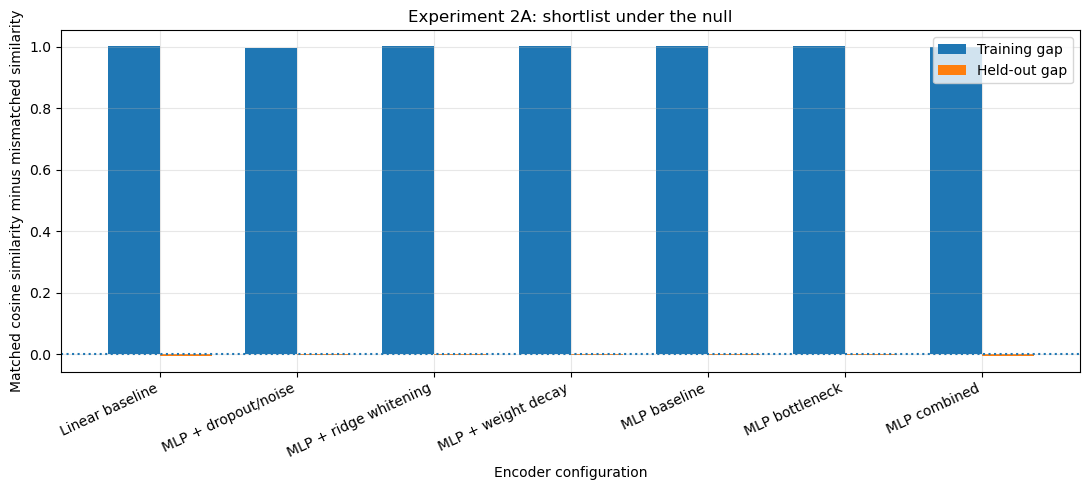

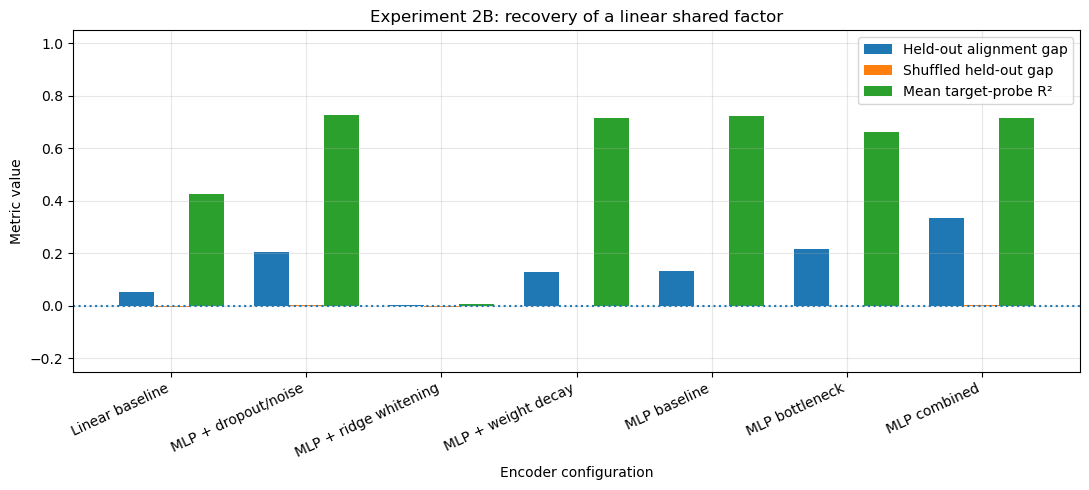

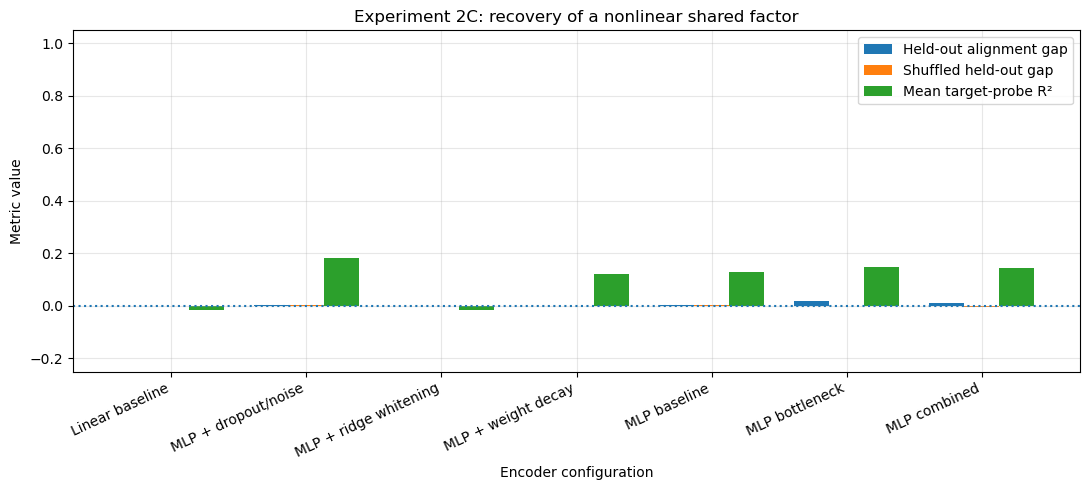

In [ ]:
configs_shortlist = [
    LINEAR_BASELINE,
    MLP_BASELINE,
    replace(
        MLP_BASELINE,
        name="MLP bottleneck",
        embedding_dim=4,
    ),
    replace(
        MLP_BASELINE,
        name="MLP + weight decay",
        weight_decay=1e-3,
    ),
    replace(
        MLP_BASELINE,
        name="MLP + dropout/noise",
        dropout=0.25,
        feature_dropout=0.10,
        gaussian_noise_std=0.05,
    ),
    replace(
        MLP_BASELINE,
        name="MLP combined",
        embedding_dim=4,
        weight_decay=1e-3,
        dropout=0.25,
        feature_dropout=0.10,
        gaussian_noise_std=0.05,
        consistency_strength=0.10,
        consistency_noise_std=0.10,
    ),
    replace(
        MLP_BASELINE,
        name="MLP + ridge whitening",
        whitening_ridge=0.10,
    ),
]

exp_shortlist = run_config_grid(
    configs=configs_shortlist,
    scenarios=["Null", "Linear signal", "Quadratic signal"],
    n_train=N_TRAIN,
    n_test=N_TEST,
    p=P,
    q=Q,
    n_rep=N_REP,
    signal_strength=SIGNAL_STRENGTH,
    noise_std=NOISE_STD,
    seed=GLOBAL_SEED + 20,
)

summary_shortlist = summarize_results(exp_shortlist)
display(summary_shortlist.round(4))

plot_null_alignment(
    exp_shortlist,
    "Experiment 2A: shortlist under the null",
)

plot_signal_metrics(
    exp_shortlist,
    scenario="Linear signal",
    title="Experiment 2B: recovery of a linear shared factor",
)

plot_signal_metrics(
    exp_shortlist,
    scenario="Quadratic signal",
    title="Experiment 2C: recovery of a nonlinear shared factor",
)

### Reading Experiment 2

The linear baseline is expected to work best on a linearly shared factor. It may struggle in the quadratic scenario because the `X` encoder must construct a squared feature.

A nonlinear encoder is useful when it improves **held-out** nonlinear-signal recovery, not merely its training score.

A method that reduces null training alignment but also destroys signal recovery has probably over-regularized or collapsed.

# Experiment 3 — Observation-noise sweep for the nonlinear relationship

This experiment varies the standard deviation of the observation noise while keeping the nonlinear shared mechanism fixed.

It compares an unregularized MLP and a combined regularized MLP. The useful question is how rapidly held-out alignment and target recovery degrade as noise increases.

Completed  15/60 noise-sweep runs in   40.0s
Completed  30/60 noise-sweep runs in   83.6s
Completed  45/60 noise-sweep runs in 1028.3s
Completed  60/60 noise-sweep runs in 3184.6s


,noise_std,config,rep,train_alignment_gap,test_alignment_gap,shuffled_test_alignment_gap,train_top1,test_top1,target_probe_r2_x,target_probe_r2_y,effective_rank_x,effective_rank_y,mean_embedding_norm_x,mean_embedding_norm_y,final_loss,mean_target_probe_r2
0,0.25,MLP baseline,2.5,1.0025,0.1158,0.0032,1.0000,0.0007,0.6652,0.8607,7.7495,7.2524,0.8327,0.8901,2.3773,0.7630
1,0.25,MLP combined,2.5,0.9983,0.2737,0.0018,0.9196,0.0011,0.6681,0.9393,3.5493,2.0613,1.3498,1.6599,3.4700,0.8037
2,0.50,MLP baseline,2.5,1.0025,0.0607,-0.0007,1.0000,0.0007,0.3768,0.6776,7.8798,7.6760,0.8507,0.8967,2.3766,0.5272
3,0.50,MLP combined,2.5,0.9984,0.1957,-0.0010,0.9346,0.0004,0.4959,0.8778,3.6922,2.3995,1.3435,1.7371,3.4633,0.6868
4,1.00,MLP baseline,2.5,1.0025,0.0031,0.0015,1.0000,0.0002,-0.0141,0.2226,7.9247,7.9164,0.8580,0.9146,2.3763,0.1043
5,1.00,MLP combined,2.5,0.9986,0.0170,-0.0020,0.9408,0.0003,0.0193,0.2537,3.9581,3.8290,1.2957,1.3856,3.4642,0.1365
6,1.50,MLP baseline,2.5,1.0025,0.0006,0.0008,1.0000,0.0006,-0.0385,0.1074,7.9367,7.9451,0.8548,0.8935,2.3764,0.0345
7,1.50,MLP combined,2.5,0.9986,0.0024,0.0101,0.9390,0.0005,-0.0067,0.0596,3.9849,3.9801,1.2966,1.2973,3.4556,0.0265
8,2.00,MLP baseline,2.5,1.0025,0.0042,0.0018,1.0000,0.0003,-0.0192,0.0558,7.9337,7.9341,0.8616,0.9061,2.3763,0.0183
9,2.00,MLP combined,2.5,0.9988,0.0005,0.0008,0.9490,0.0004,-0.0051,0.0298,3.9803,3.9819,1.2844,1.2907,3.4646,0.0123


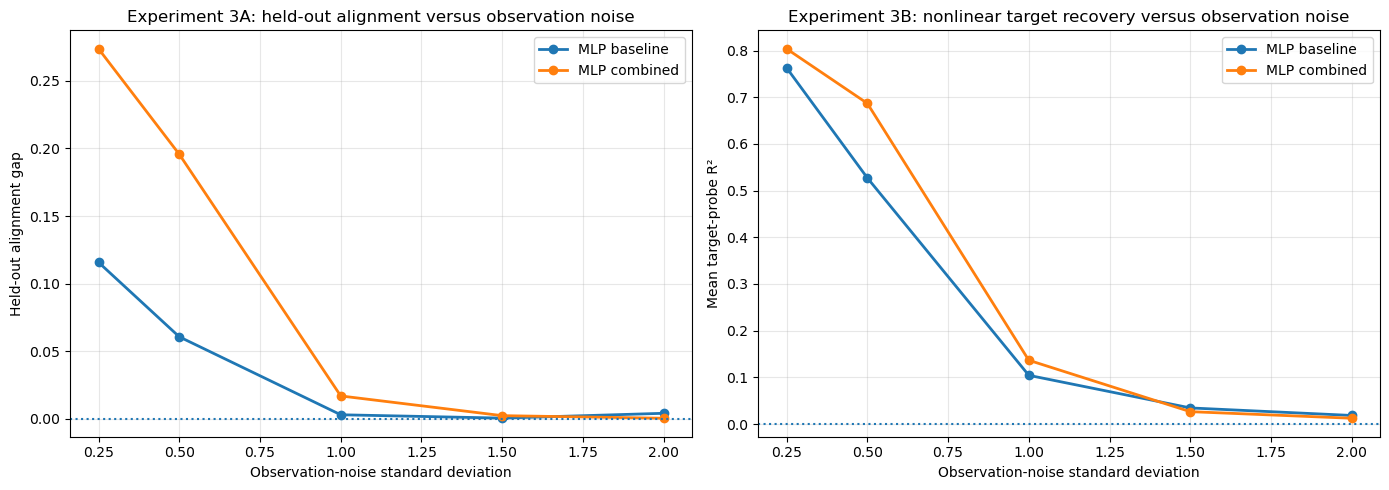

In [ ]:
def run_noise_sweep(
    configs: Sequence[TrainConfig],
    noise_values: Sequence[float],
    n_rep: int,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows: List[Dict[str, float]] = []

    total_runs = len(noise_values) * len(configs) * n_rep
    completed = 0
    start_time = time.time()

    for noise_std in noise_values:
        for rep in range(n_rep):
            dataset = generate_quadratic_signal_dataset(
                n_train=N_TRAIN,
                n_test=N_TEST,
                p=P,
                q=Q,
                signal_strength=SIGNAL_STRENGTH,
                noise_std=float(noise_std),
                rng=rng,
            )

            for config_index, config in enumerate(configs):
                metrics = train_and_evaluate(
                    dataset=dataset,
                    config=config,
                    seed=seed + 1000 * rep + config_index,
                )

                rows.append(
                    {
                        "noise_std": float(noise_std),
                        "rep": rep,
                        "config": config.name,
                        **metrics,
                    }
                )

                completed += 1
                if completed == total_runs or completed % max(1, total_runs // 4) == 0:
                    elapsed = time.time() - start_time
                    print(f"Completed {completed:>3}/{total_runs} noise-sweep runs in {elapsed:6.1f}s")

    return pd.DataFrame(rows)


REGULARIZED_MLP = replace(
    MLP_BASELINE,
    name="MLP combined",
    embedding_dim=4,
    weight_decay=1e-3,
    dropout=0.25,
    feature_dropout=0.10,
    gaussian_noise_std=0.05,
    consistency_strength=0.10,
    consistency_noise_std=0.10,
)

NOISE_VALUES = (
    [0.25, 1.00, 2.00]
    if QUICK_MODE
    else [0.25, 0.50, 1.00, 1.50, 2.00]
)

exp_noise_sweep = run_noise_sweep(
    configs=[MLP_BASELINE, REGULARIZED_MLP],
    noise_values=NOISE_VALUES,
    n_rep=N_REP,
    seed=GLOBAL_SEED + 30,
)

summary_noise_sweep = (
    exp_noise_sweep.groupby(["noise_std", "config"], as_index=False)
    .mean(numeric_only=True)
)

summary_noise_sweep["mean_target_probe_r2"] = 0.5 * (
    summary_noise_sweep["target_probe_r2_x"]
    + summary_noise_sweep["target_probe_r2_y"]
)

display(summary_noise_sweep.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for config_name in summary_noise_sweep["config"].unique():
    subset = summary_noise_sweep[summary_noise_sweep["config"] == config_name]

    axes[0].plot(
        subset["noise_std"],
        subset["test_alignment_gap"],
        marker="o",
        linewidth=2,
        label=config_name,
    )

    axes[1].plot(
        subset["noise_std"],
        subset["mean_target_probe_r2"],
        marker="o",
        linewidth=2,
        label=config_name,
    )

axes[0].axhline(0.0, linestyle=":")
axes[0].set(
    title="Experiment 3A: held-out alignment versus observation noise",
    xlabel="Observation-noise standard deviation",
    ylabel="Held-out alignment gap",
)
axes[0].legend()

axes[1].axhline(0.0, linestyle=":")
axes[1].set(
    title="Experiment 3B: nonlinear target recovery versus observation noise",
    xlabel="Observation-noise standard deviation",
    ylabel="Mean target-probe R²",
)
axes[1].legend()

plt.tight_layout()
plt.show()

# Experiment 4 — A compact final table

This table combines the most important diagnostics. It is useful for deciding which settings deserve a more expensive replication sweep.

In [ ]:
final_table = summary_shortlist.copy()
final_table["mean_target_probe_r2"] = average_probe_r2(final_table)
final_table["mean_effective_rank"] = 0.5 * (
    final_table["effective_rank_x"]
    + final_table["effective_rank_y"]
)

final_table = final_table[
    [
        "scenario",
        "config",
        "train_alignment_gap",
        "test_alignment_gap",
        "shuffled_test_alignment_gap",
        "train_top1",
        "test_top1",
        "mean_target_probe_r2",
        "mean_effective_rank",
    ]
]

display(final_table.round(4))

final_table.to_csv(
    "nonlinear_contrastive_shortlist_summary.csv",
    index=False,
)

exp_capacity.to_csv(
    "nonlinear_contrastive_capacity_runs.csv",
    index=False,
)

exp_shortlist.to_csv(
    "nonlinear_contrastive_shortlist_runs.csv",
    index=False,
)

exp_noise_sweep.to_csv(
    "nonlinear_contrastive_noise_sweep_runs.csv",
    index=False,
)

print("Saved CSV result files in the current working directory.")

,scenario,config,train_alignment_gap,test_alignment_gap,shuffled_test_alignment_gap,train_top1,test_top1,mean_target_probe_r2,mean_effective_rank
0,Linear signal,Linear baseline,1.0024,0.0546,-0.0026,1.0000,0.0005,0.4260,7.9139
1,Linear signal,MLP + dropout/noise,0.9955,0.2042,0.0048,1.0000,0.0009,0.7285,6.9778
2,Linear signal,MLP + ridge whitening,1.0025,0.0043,-0.0023,1.0000,0.0003,0.0077,7.8638
3,Linear signal,MLP + weight decay,1.0025,0.1276,0.0014,1.0000,0.0009,0.7146,7.7691
4,Linear signal,MLP baseline,1.0025,0.1314,0.0011,1.0000,0.0008,0.7237,7.7578
5,Linear signal,MLP bottleneck,1.0025,0.2176,0.0000,1.0000,0.0014,0.6627,3.8398
6,Linear signal,MLP combined,0.9990,0.3357,0.0027,0.9544,0.0009,0.7159,3.4262
7,Null,Linear baseline,1.0025,-0.0052,-0.0026,1.0000,0.0002,NaN,7.9238
8,Null,MLP + dropout/noise,0.9958,-0.0019,0.0026,1.0000,0.0003,NaN,7.3849
9,Null,MLP + ridge whitening,1.0025,-0.0010,-0.0049,1.0000,0.0004,NaN,7.8369


Saved CSV result files in the current working directory.


# Interpretation checklist

A nonlinear encoder **fails the null-noise test** when it has high training alignment or high training retrieval on independent views but its held-out scores collapse to zero. That is memorization.

A nonlinear encoder is useful when:

1. null held-out alignment remains close to zero;
2. shuffled held-out alignment remains close to zero;
3. correctly paired held-out alignment is positive when a shared factor exists;
4. target-probe R² is positive on unseen samples;
5. effective rank remains above zero, so the representation has not merely collapsed.

## Important limitation

The nonlinear encoder is not expected to eliminate all overfitting automatically. Compared with a linear encoder, an MLP has greater capacity and may memorize null pairings more aggressively. The notebook is designed to reveal that distinction.

## Recommended next run

After the quick run succeeds:

```python
QUICK_MODE = False
```

Then rerun the notebook. The larger number of replications makes the conclusions more reliable.